# Supplementary Fig. 47 & Supplementary Table 9 — uncertainty on fitness and establishment-time estimates

Each clone's fitness and establishment time is inferred by a maximum-likelihood optimiser run from
**25 independent random seeds** (`Code_for_inferring_acquisition_age_and_fitness_v16.py`). Seeds whose
final likelihood falls within **±20 %** of the best (lowest) log-likelihood for that sample are retained;
the spread of those retained seeds is what quantifies confidence in the inferred parameters.

The optimiser records the retained seeds per clone in the `Seed_results` column of its output table. This
notebook reads that column, computes the **standard deviation** and the **95 % optimiser range**
(2.5th–97.5th percentile) of fitness and establishment age for every clone.

| output | what it is |
|---|---|
| `Data_files/All_fitness_establishment_times_with_sd_and_CI.csv` | **Supplementary Table 9** — fitness, tau, establishment age, S.D. and 95 % range for every clone |
| `Figures_seeds_results_with_CI/*.pdf` | **Supplementary Fig. 47** — one panel per individual |

## Data availability

| file | used for | location |
|---|---|---|
| `Optimiser_results_v15.txt` | inferred fitness, tau, establishment ages, clone colours and the retained per-seed results | Data_files |
| `UKCTOCS_samples_processed_information.csv` | AML diagnosis age, which sets the figure's x-axis limit | EGA |

The sample information file is individual-level participant data, available under controlled access,
deposited in the European Genome-phenome Archive (EGA) and released to approved researchers via a Data
Access Committee administered by the corresponding authors. Section 1 runs without it; section 2 falls
back to the range of the seed results when it is absent.


## Imports and colours

In [17]:
import ast
import csv
import os
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [18]:
#define the colors from colorbrewer2
grey1 = '#f7f7f7'
grey2 = '#cccccc'
grey3 = '#969696'
grey4 = '#636363'
grey5 = '#252525'

## Helper functions

In [19]:
def parse_seed_results(raw_str):
    """Strip any trailing timestamp (or other junk) after the closing brace."""
    match = re.search(r'\}(?=[^}]*$)', raw_str)
    if match:
        raw_str = raw_str[:match.end()]
    return ast.literal_eval(raw_str)


def compute_empirical_95_range(arr):
    if len(arr) > 1:
        lower, upper = np.percentile(arr, [2.5, 97.5])
        # round() can return -0.0; normalise it so the printed range reads 0.0
        return f"{round(lower, 2) + 0.0} - {round(upper, 2) + 0.0}"
    else:
        return np.nan


def lower_upper_95_range(arr):
    if len(arr) > 1:
        return np.percentile(arr, [2.5, 97.5])
    else:
        return np.nan, np.nan

## 1. Supplementary Table 9 — S.D. and 95 % optimiser range per clone

In [20]:
def summarise_sample(sample_name, mapping_df):
    """Per-clone point estimates, S.D. and 95% optimiser range for one sample."""
    sample_rows = mapping_df[mapping_df['Sample_name'] == sample_name]
    if sample_rows.empty:
        raise ValueError(f"Sample {sample_name} not found in the optimiser results")

    # if a sample was optimised more than once, keep the run with the best (lowest) likelihood
    row = sample_rows.loc[sample_rows['Best_likelihood'].idxmin()]

    fitnesses_dict    = ast.literal_eval(row['Fitnesses'])
    tau_times_dict    = ast.literal_eval(row['Tau_times'])
    est_times_dict    = ast.literal_eval(row['Establishment_ages'])
    clone_color_map   = ast.literal_eval(row['Clone_colors'])
    seed_results_dict = parse_seed_results(row['Seed_results'])

    long_rows = []
    for canonical_clone, seed_points in seed_results_dict.items():
        if not seed_points:
            continue
        if clone_color_map.get(canonical_clone) is None:
            continue

        x_vals, y_vals = (list(v) for v in zip(*seed_points))
        fitness_val = fitnesses_dict.get(canonical_clone, np.nan)
        tau_val     = tau_times_dict.get(canonical_clone, np.nan)
        est_val     = est_times_dict.get(canonical_clone, np.nan)

        long_rows.append({
            'Sample_name':            sample_name,
            'Clone':                  str(canonical_clone).replace("'", "").strip("(), "),
            'Fitness':                round(fitness_val * 100, 2) if pd.notnull(fitness_val) else np.nan,
            'Tau_time':               round(tau_val, 2)           if pd.notnull(tau_val)     else np.nan,
            'Establishment_time':     round(est_val, 2)           if pd.notnull(est_val)     else np.nan,
            'Seed results':           list(zip(x_vals, y_vals)),
            'S.D. fitness':           round(np.std(y_vals, ddof=1), 2) if len(y_vals) > 1 else np.nan,
            'S.D. establishment age': round(np.std(x_vals, ddof=1), 2) if len(x_vals) > 1 else np.nan,
            '95% optimizer result range fitness':           compute_empirical_95_range(y_vals),
            '95% optimizer result range establishment age': compute_empirical_95_range(x_vals),
        })

    return pd.DataFrame(long_rows)

In [21]:
mapping_df = pd.read_csv("Data_files/Optimiser_results_v15.txt", sep='\t')

samples = sorted(mapping_df.loc[mapping_df['Seed_results'].notna(), 'Sample_name'].unique())
print(f"{len(samples)} samples with per-seed results")

combined_df = pd.concat([summarise_sample(s, mapping_df) for s in samples], ignore_index=True)
combined_df = combined_df.sort_values(['Sample_name', 'Establishment_time']).reset_index(drop=True)

print(f"{len(combined_df)} clones across {combined_df['Sample_name'].nunique()} samples")
combined_df.to_csv("Data_files/All_fitness_establishment_times_with_sd_and_CI.csv", index=False)
# combined_df.head(10)

75 samples with per-seed results
222 clones across 75 samples


## 2. Supplementary Fig. 47 — seed distributions with 95 % optimiser ranges

All of an individual's clones on one axes, coloured by clone. Circles are the retained seeds, the cross is the best seed (the reported estimate), and the horizontal and vertical bars are the 95 % optimiser ranges for establishment time and fitness. Panels **a** and **b** of the published figure are `C92_002` and `C92_086`.

In [22]:
def diagnosis_age_for(sample_ID):
    """AML diagnosis age, used only to set the x-axis limit. Returns None if the
    (controlled-access) sample information file is not present."""
    path = 'Data_files/UKCTOCS_samples_processed_information.csv'
    if not os.path.exists(path):
        return None

    sample_diagnosis_age = {}   #e.g. {'C92_002': 81.1, 'C92_003': 75.21...}
    matched_sample = {}         #e.g. {'C92_002': 'CNTRL_169', 'C92_003': 'CNTRL_002'...}

    with open(path) as csvfile:
        readreader = csv.reader(csvfile)
        row_count = 0
        for row in readreader:
            if row_count > 0:
                sample_name = row[1].split('_')[0] + '_' + row[1].split('_')[1]

                if row[9] != '' and '_' in row[9]:
                    matched_sample[sample_name] = row[9].split('_')[0] + '_' + row[9].split('_')[1]

                if row[0] == 'Case':
                    sample_diagnosis_age[sample_name] = float(row[7])

                if row[0] == 'Control' and sample_name in matched_sample:
                    sample_diagnosis_age[sample_name] = sample_diagnosis_age[matched_sample[sample_name]]

            row_count += 1

    return sample_diagnosis_age.get(sample_ID)

In [23]:
def plot_seeds(sample_name, mapping_df, save=True):
    row = mapping_df.loc[mapping_df[mapping_df['Sample_name'] == sample_name]['Best_likelihood'].idxmin()]

    fitnesses_dict    = ast.literal_eval(row['Fitnesses'])
    est_times_dict    = ast.literal_eval(row['Establishment_ages'])
    clone_color_map   = ast.literal_eval(row['Clone_colors'])
    seed_results_dict = parse_seed_results(row['Seed_results'])

    diagnosis_age = diagnosis_age_for(sample_name)

    plt.figure(figsize=(9, 8))
    establishment_times, fitnesses = [], []

    for clone, seed_points in seed_results_dict.items():
        color = clone_color_map.get(clone)
        if color is None or not seed_points:
            continue

        x_vals, y_vals = (list(v) for v in zip(*seed_points))
        establishment_times += x_vals
        fitnesses += y_vals

        best_est = est_times_dict.get(clone, np.nan)
        best_fit = fitnesses_dict.get(clone, np.nan)
        best_fit = best_fit * 100 if pd.notnull(best_fit) else np.nan

        #plot all the seeds...
        plt.scatter(x_vals, y_vals, c=color, edgecolor='k', zorder=20, lw=1.0, s=200, alpha=0.5)
        #plot most likely...
        plt.scatter(best_est, best_fit, color=color, edgecolor='k', marker='X',
                    alpha=0.85, lw=2, s=450, zorder=200, label=str(clone).replace("'", "").strip("(), "))

        #plot the confidence intervals...
        lo_est, hi_est = lower_upper_95_range(x_vals)
        lo_fit, hi_fit = lower_upper_95_range(y_vals)

        plt.plot([lo_est, hi_est], [best_fit - 8, best_fit - 8], color=color, lw=2)
        plt.scatter([lo_est, hi_est], [best_fit - 8, best_fit - 8], marker='|', color=color, s=350, lw=2)

        plt.plot([best_est - 5, best_est - 5], [lo_fit, hi_fit], color=color, lw=2)
        plt.scatter([best_est - 5, best_est - 5], [lo_fit, hi_fit], marker='_', color=color, s=350, lw=2)

    ax = plt.gca()
    x_upper = max(establishment_times) + 5
    if diagnosis_age is not None:
        x_upper = max(x_upper, diagnosis_age + 5)
    ax.set_xlim(min(establishment_times) - 5, x_upper)
    ax.set_ylim(0, max(fitnesses) * 1.15)

    plt.title(sample_name)
    ax.set_ylabel('fitness (% per year)', fontsize=21)
    ax.set_xlabel('establishment time (years)', fontsize=21)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.yaxis.set_tick_params(width=1.5, color=grey3, length=6)
    ax.xaxis.set_tick_params(width=1.5, color=grey3, length=6)
    ax.tick_params(axis='both', which='major', labelsize=21)
    ax.grid(zorder=0, color=grey2)
    for axis in ['bottom', 'left']:
        ax.spines[axis].set_linewidth(1.5)
        ax.spines[axis].set_color(grey3)

    plt.tight_layout()
    if save:
        os.makedirs('Figures_seeds_results_with_CI', exist_ok=True)
        plt.savefig(f'Figures_seeds_results_with_CI/{sample_name}_seed_results_25_seeds_with_CI.pdf')
    plt.show()

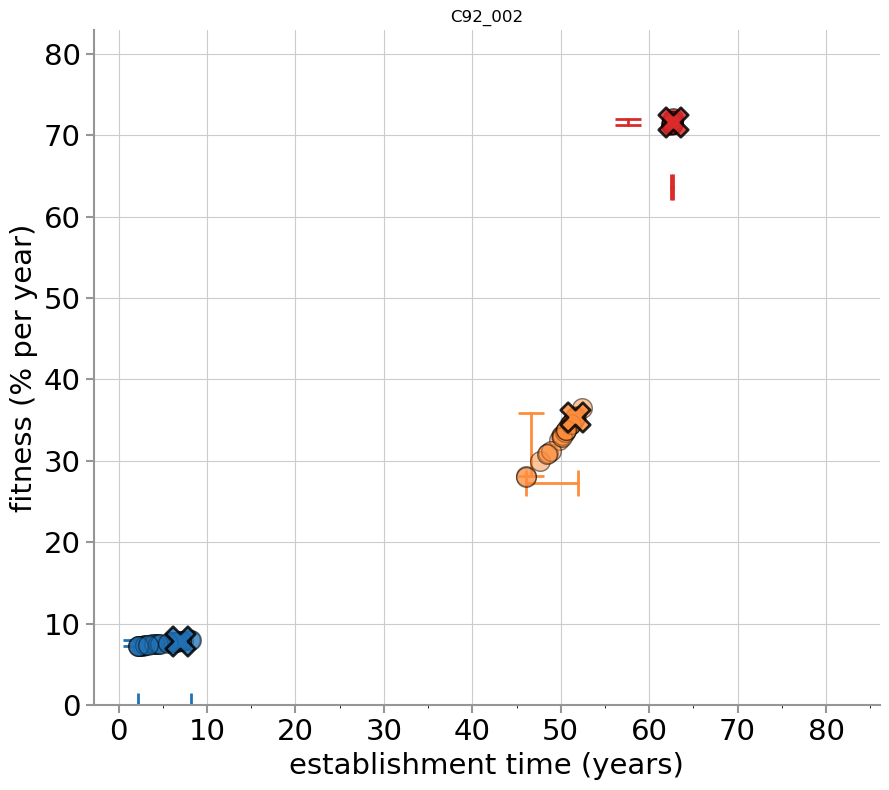

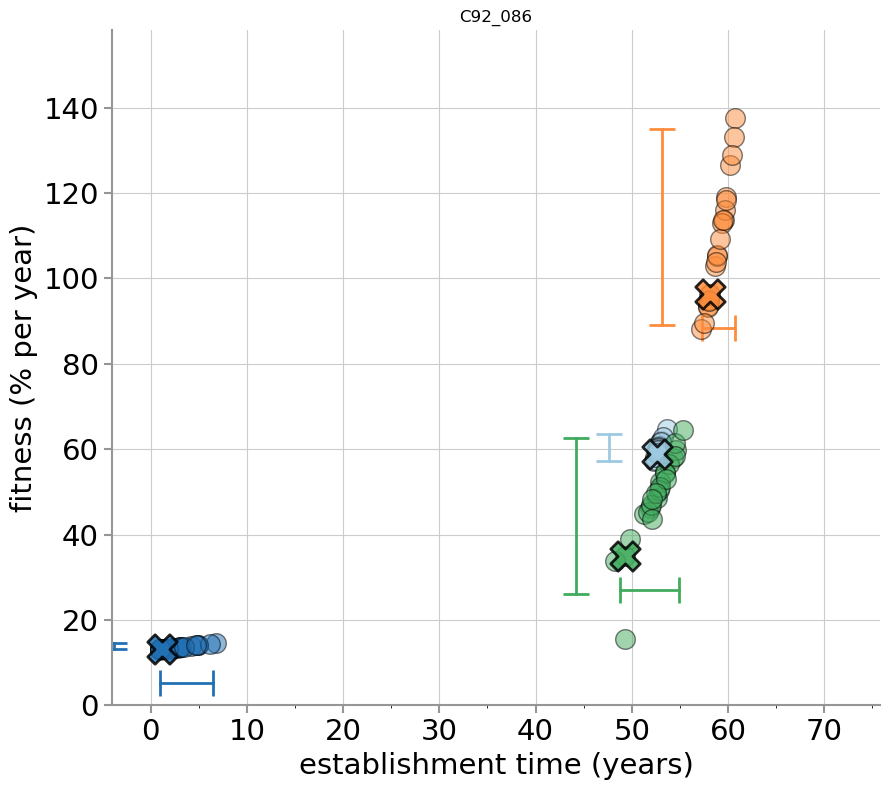

In [24]:
# Panels a and b of the published figure.
for sample_name in ['C92_002', 'C92_086']:
    plot_seeds(sample_name, mapping_df)